In [1]:
# Importar utils
import sys
sys.path.append('..')
from utils.bootcampviztools import *
from utils.toolbox import *

# Common imports
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from functools import reduce


# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [2]:
#recordad hacer pip install fastparquet y usar este codigo cuando lo abrais:
df_reg = pd.read_parquet('../data_sample/datos_licitaciones.parquet', engine='fastparquet')

In [3]:
df_reg.head()

,Situació contractual,Exercici,Àmbit organitzatiu,Identificador agrupació organisme,Agrupació organisme,Identificador organisme contractant,Organisme contractant,Codi de l’expedient,Procediment d’adjudicació,Tipus de contracte,...,Tipus de modificació,Import de la modificació,Data aprovació modificació,Termini modificació anys,Termini modificació mesos,Termini modificació dies,Tipus de liquidació,Data de liquidació,Causa de resolució,Import de la liquidació
572837,liquidació,2022,Entitats de l'Administració Local,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,4316280001,Ajuntament de Vandellòs i l'Hospitalet de l'In...,0225 / 2022,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,08/02/2022,,2.38
609033,liquidació,2023,Departaments i Sector Públic de la Generalitat...,1500,DEPARTAMENT DE SALUT,1542,Institut Català de la Salut (ICS) Barcelonès H...,1101369832,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,14/11/2023,,170.68
1612984,liquidació,2024,Entitats de l'Administració Local,0822050006,Ajuntament de Sant Julià de Vilatorta,0822050006,Ajuntament de Sant Julià de Vilatorta,SU41,Menor,3. SUBMINISTRAMENTS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,13/05/2024,,45.81
1412433,liquidació,2021,Departaments i Sector Públic de la Generalitat...,1400,DEPARTAMENT DE CULTURA,7915100002,Biblioteca de Catalunya,BC-2021-135,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,15/06/2021,,2150.13
951405,liquidació,2025,Entitats de l'Administració Local,8000840003,Diputació de Barcelona,8000840003,Diputació de Barcelona,2025/4118 - 9,Menor,5. SERVEIS,...,,NaN,,NaN,NaN,NaN,COMPLIMENT,25/03/2025,,880.00


In [4]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37700 entries, 572837 to 2087811
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Situació contractual                 37700 non-null  object 
 1   Exercici                             37700 non-null  int64  
 2   Àmbit organitzatiu                   37700 non-null  object 
 3   Identificador agrupació organisme    37700 non-null  object 
 4   Agrupació organisme                  37700 non-null  object 
 5   Identificador organisme contractant  37700 non-null  object 
 6   Organisme contractant                37700 non-null  object 
 7   Codi de l’expedient                  37700 non-null  object 
 8   Procediment d’adjudicació            37700 non-null  object 
 9   Tipus de contracte                   37700 non-null  object 
 10  Descripció de l’expedient            37700 non-null  object 
 11  Número de lot             

Antes de hacer el split dedidimos cuál es nuestra target y hacemos una revisión de missings

In [5]:
target = 'Import de la liquidació'

In [6]:
df_reg[target].describe()

count    3.770000e+04
mean     2.871306e+03
std      2.989103e+04
min     -3.570100e+02
25%      1.458950e+02
50%      4.800000e+02
75%      1.620000e+03
max      4.013769e+06
Name: Import de la liquidació, dtype: float64

In [7]:
# Registros con valor target <=0 
negativos = df_reg[df_reg[target] <= 0].shape[0]
print(f"Registros con valor {target} <= 0: {negativos} {negativos/df_reg.shape[0]*100:.2f}%")

Registros con valor Import de la liquidació <= 0: 47 0.12%


In [8]:
# Eliminar los registros donde el valor de la variable target es menor a 0
# los trataremos una vez entrenado el modelo
df_copia = df_reg[df_reg[target] > 0]
print(f"Registros restantes: {len(df_copia)}")

Registros restantes: 37653


In [9]:
# Hacemos el split
X_train, X_test, y_train, y_test = train_test_split(df_copia.drop(target, axis=1),
                                                     df_copia[target],
                                                     test_size=0.2,
                                                     random_state=42)

<Axes: xlabel='Import de la liquidació', ylabel='Count'>

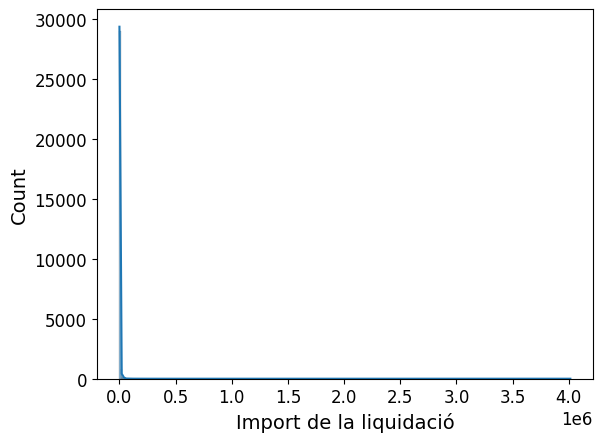

In [10]:
# Distribución de la variable target
sns.histplot(y_train, kde=True)

<Axes: xlabel='Import de la liquidació', ylabel='Count'>

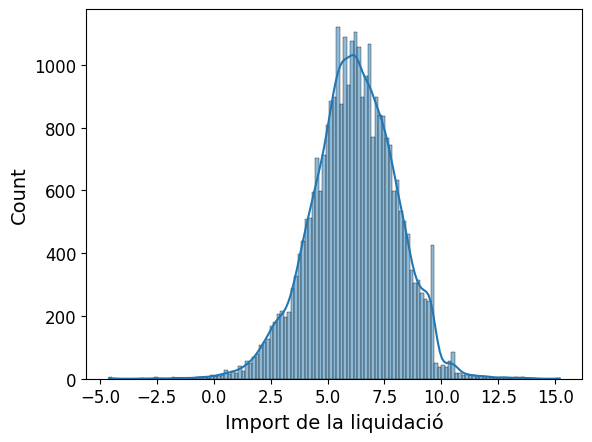

In [11]:
# Aplicamos logaritmo a la variable target para reducir su asimetría
y_train_log = np.log(y_train)
sns.histplot(y_train_log, kde=True)

In [12]:
# Iré guardando los pasos que aplicaré a X_train en un pipeline
# para después aplicarlo a X_test
# Pipeline inicial
pipeline_steps = []

# Eliminar todos los apóstrofes de los nombres de columnas y de los datos tipo string y pasar a minúsculas
tratar_strings(X_train)
pipeline_steps.append(lambda df: tratar_strings(df))

#X_test = reduce(lambda acc, func: func(acc), pipeline_steps, X_test)



In [13]:
# Porcentage coincidencia de las columnas importe con target, si es > 95% las eliminamos:
reporte = data_report(X_train).reset_index()
columnas_importe = reporte[reporte['COL_N'].astype(str).str.startswith('Import')]['COL_N']

similitud_con_target(X_train, y_train, columnas_importe, pipeline_steps)


Porcentage coincidencia Import dadjudicació / Import de la liquidació: 97.35%
Se elimina columna: Import dadjudicació
Porcentage coincidencia Import de la modificació / Import de la liquidació: 0.00%


In [14]:
# # Codi CPV
# # https://contratos.gobierto.es/cpv
# # https://www.licitaciones.es/blog/codigos-cpv
# # https://record.bibliotecadigital.gencat.cat/handle/20.500.14345/2167
# df_cpv = pd.read_csv('../data_sample/CPV.csv', sep=';')

# tratar_codi_cpv(X_train)
# pipeline_steps.append(lambda df: tratar_codi_cpv(df))

In [15]:
# Tratamiento Missings
data_report(X_train).sort_values(by='MISSINGS (%)', ascending=False)

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
COL_N,,,,
Import de la modificació,float64,100.0,0,0.00
Número de modificació,float64,100.0,0,0.00
Termini modificació anys,float64,100.0,0,0.00
Termini modificació mesos,float64,100.0,0,0.00
Termini modificació dies,float64,100.0,0,0.00
Número de pròrroga,float64,100.0,0,0.00
Situació contractual,object,0.0,1,0.00
Exercici,int64,0.0,9,0.03
Àmbit organitzatiu,object,0.0,3,0.01


In [16]:
# Eliminar las columnas con más del 60% de valores nulos
eliminar_columnas_nulas(X_train, pipeline_steps)


Total de columnas vacías: 10

Se elimina columna: Número de pròrroga
Se elimina columna: Data inici pròrroga
Se elimina columna: Data fi pròrroga
Se elimina columna: Número de modificació
Se elimina columna: Tipus de modificació
Se elimina columna: Import de la modificació
Se elimina columna: Data aprovació modificació
Se elimina columna: Termini modificació anys
Se elimina columna: Termini modificació mesos
Se elimina columna: Termini modificació dies


In [17]:
# Tratar columnas con algún valor en blanco, eliminaremos las que tienen más del 70% en blanco
# Para el restro informamos el valor 'otros'
tratar_columnas_con_algun_blanco(X_train, pipeline_steps)


Columnas con algún blanco:

Columna con blancos: Procediment dadjudicació 16 0.05%
Columna con blancos: Codi CPV 19749 65.56%
Se elimina columna: Causa de resolució 30113 99.97%


In [18]:
# Tratar columnas con algún valor 0, eliminaremos las que tienen más del 70% 0
tratar_columnas_con_algun_cero(X_train, pipeline_steps)

Columnas con algún cero:

Se elimina columna: Durada dies 21755 72.22%
Se elimina columna: Durada mesos 26191 86.95%
Se elimina columna: Durada anys 29477 97.86%


In [19]:
# Estudio cardinalidades
data_report(X_train).sort_values(by='UNIQUE_VALUES')

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
COL_N,,,,
Situació contractual,object,0.0,1,0.00
Lot desert,object,0.0,1,0.00
Tipus de liquidació,object,0.0,2,0.01
Àmbit organitzatiu,object,0.0,3,0.01
Tipus de contracte,object,0.0,7,0.02
Procediment dadjudicació,object,0.0,8,0.03
Exercici,int64,0.0,9,0.03
Número de lot,int64,0.0,21,0.07
Identificador agrupació organisme,object,0.0,559,1.86


In [20]:
# Eliminar las columnas con cardinalidad 0 o mayor que 60%
tratar_cardinalidad(X_train, pipeline_steps)

Total de columnas con cardinalidad 0 o mayor que 60.0%: 5

Se elimina columna: Situació contractual (1 valores únicos, 0.00%)
Se elimina columna: Lot desert (1 valores únicos, 0.00%)
Se elimina columna: Codi de lexpedient (29824 valores únicos, 99.01%)
Se elimina columna: Descripció de lexpedient (25345 valores únicos, 84.14%)
Se elimina columna: Descripció del lot (25346 valores únicos, 84.14%)


In [21]:
# Durada será Data adjudicació - Data liquidació
# Convertir columnas de fecha DD/MM/YYYY a formato timestamp
fechas(X_train)
pipeline_steps.append(lambda df: fechas(df))


Fechas incongruentes Data de liquidació: 
2497331    30/04/0022
1813579    12/06/0024
Name: Data de liquidació, dtype: object

Fechas corregidas: Data de liquidació
30/04/2022
12/06/2024


In [22]:
# Verificamos si las columnas año son redundantes comparando con la columna Exercici
similitud_con_exercici(X_train, pipeline_steps)

In [23]:
data_report(X_train)

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
COL_N,,,,
Exercici,int64,0.0,9,0.03
Àmbit organitzatiu,object,0.0,3,0.01
Identificador agrupació organisme,object,0.0,559,1.86
Agrupació organisme,object,0.0,561,1.86
Identificador organisme contractant,object,0.0,821,2.73
Organisme contractant,object,0.0,839,2.79
Procediment dadjudicació,object,0.0,8,0.03
Tipus de contracte,object,0.0,7,0.02
Número de lot,int64,0.0,21,0.07


In [24]:
# EDA: Relación de columnas de X_train con y_train_log

# Separar columnas numéricas, objeto y fecha
num_cols = X_train.select_dtypes(include=['number']).columns
obj_cols = X_train.select_dtypes(include=['object']).columns
date_cols = X_train.select_dtypes(include=['datetime']).columns

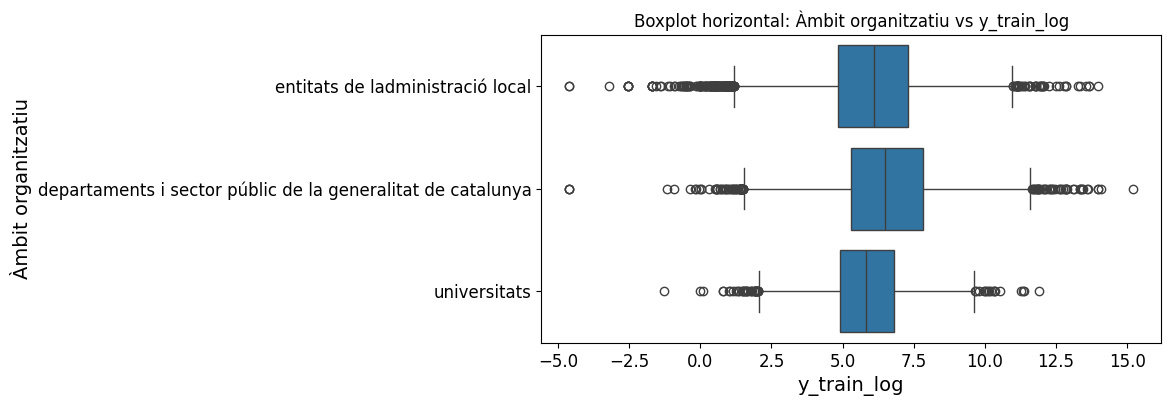

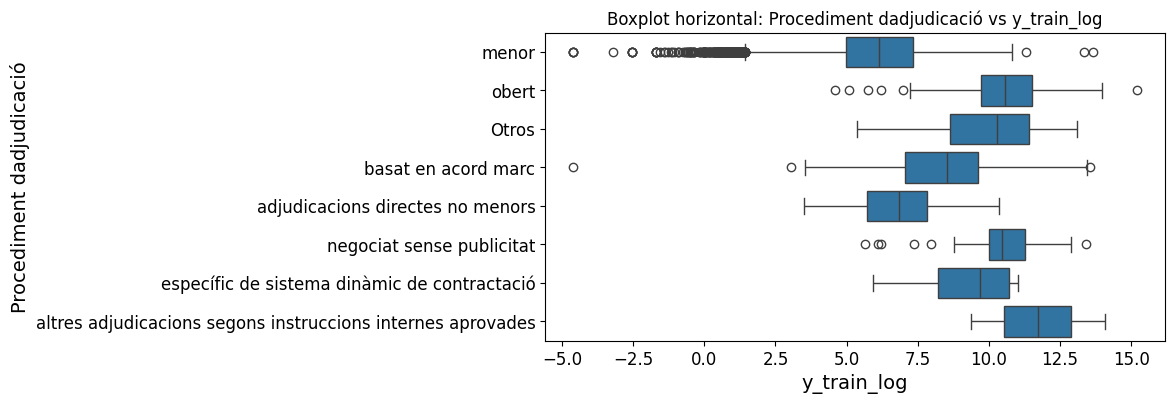

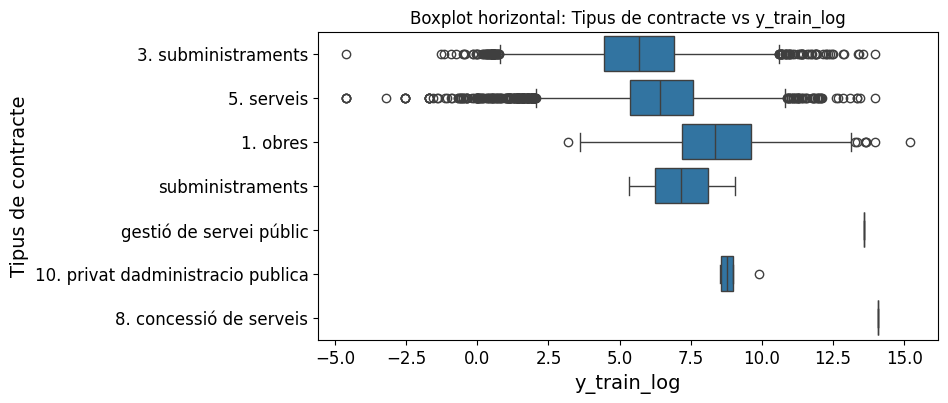

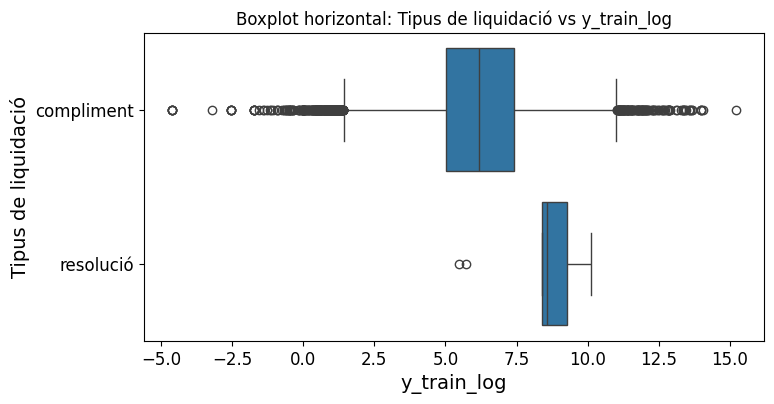

In [25]:
# Boxplots horizontales para columnas objeto (categorías con menos de 20 valores únicos)
for col in obj_cols:
    if X_train[col].nunique() <= 20:
        plt.figure(figsize=(8,4))
        sns.boxplot(y=X_train[col], x=y_train_log, orient='h')
        plt.title(f'Boxplot horizontal: {col} vs y_train_log')
        plt.ylabel(col)
        plt.xlabel('y_train_log')
        plt.show()


Vemos que las categorías de cada categórica muestran diferentes boxplot, quizá "Ambit exploratiu" es para la que los boxplot de cada categoría es parecido


Columna: Data dadjudicació
Nulos: 0
Min: 2010-11-23 00:00:00
Max: 2026-07-26 00:00:00


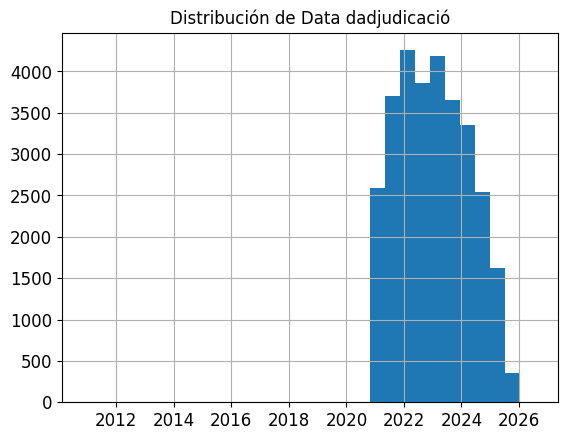


Columna: Data de liquidació
Nulos: 0
Min: 2012-11-22 00:00:00
Max: 2202-12-31 00:00:00


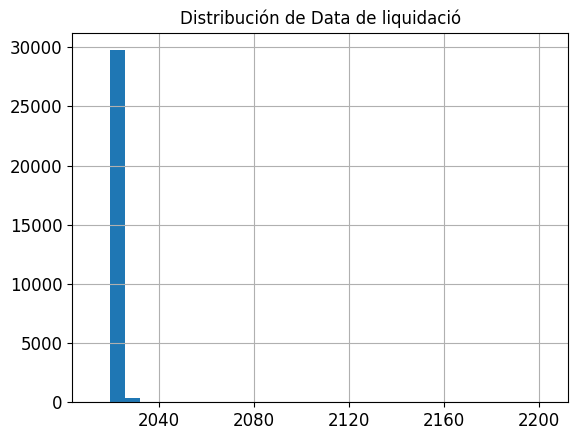

In [26]:
# EDA de columnas de fecha

# Analiza valores mínimos, máximos y nulos en columnas de fecha
for col in date_cols:
    print(f'\nColumna: {col}')
    print('Nulos:', X_train[col].isnull().sum())
    try:
        print('Min:', X_train[col].min())
        print('Max:', X_train[col].max())
        X_train[col].hist(bins=30)
        plt.title(f'Distribución de {col}')
        plt.show()
    except Exception as e:
        print('Error al analizar la columna:', e)

Vemos como hay fechas mal erróneas como Data de liquidació = 31/12/2202
Esto lo arreglaremos en el featuring engineering

A parte de esto crearemos nuevas features como día de la fecha, mes, año y fecha numérica (dif con 1/1/1970)

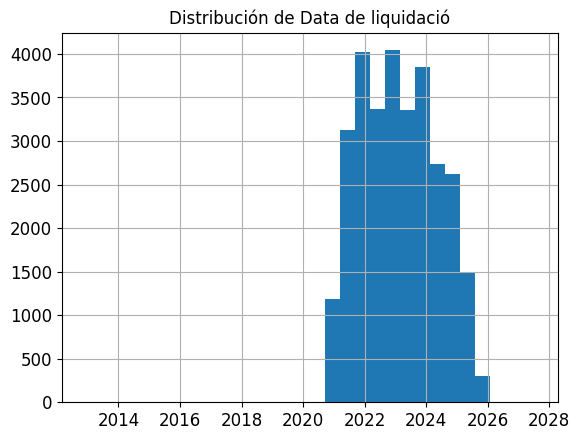

In [27]:
# Distribución de la columna 'Data de liquidació' filtrando años menores a 2030 para evitar outliers
col = 'Data de liquidació'
X_train[col][X_train[col].dt.year < 2030].hist(bins=30)
plt.title(f'Distribución de {col}')
plt.show()

In [28]:
# Correlación numérica con el target log
corrs = X_train[num_cols].corrwith(y_train_log)
print('\nCorrelación de columnas numéricas con y_train_log:')
display(corrs.sort_values(ascending=False))




Correlación de columnas numéricas con y_train_log:


Número de lot    0.016196
Exercici         0.009713
dtype: float64

Las columnas numéricas no tienen mucha correlación con la target_log

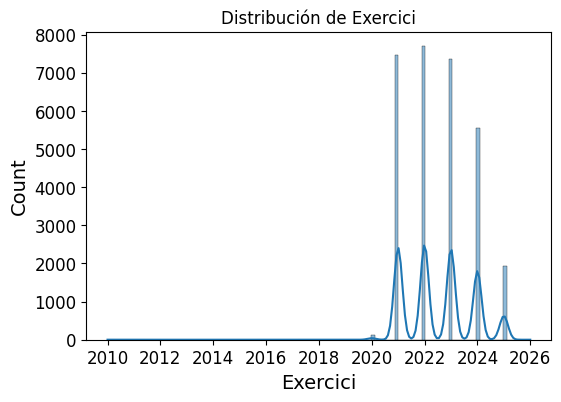

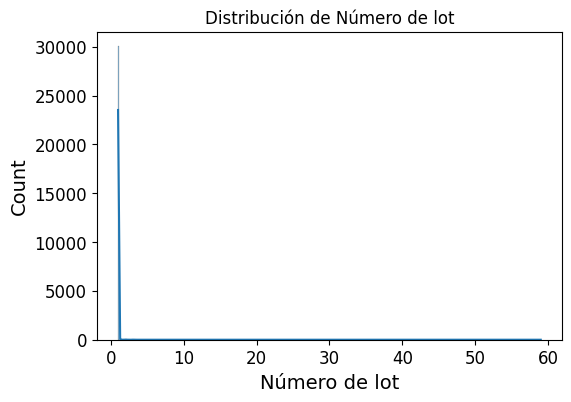

In [29]:
# Distribucion de las columnas numéricas
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()


In [71]:
col_ini = 'Data adjudicació'
col_fin = 'Data de liquidació'
duracion(X_train, col_ini, col_fin)
columnas_dt(X_train, col_ini)
columnas_dt(X_train, col_fin)
tratar_codi_cpv(X_train)

AttributeError: Can only use .dt accessor with datetimelike values